# Evaluación Programación en R - Ciencia de Datos
## Análisis de Marketing Campaign y Cafetería
---

In [2]:
library(dplyr)
library(ggplot2)
library(tidyr)
install.packages("arules")
library(arules)

options(repr.plot.width = 12, repr.plot.height = 8)
theme_set(theme_minimal())

## Carga de kuvrerpu

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘arules’


The following object is masked from ‘package:dplyr’:

    recode


The following objects are masked from ‘package:base’:

    abbreviate, write




# SECCIÓN 1 - ANÁLISIS DE CLIENTES
## P0a) Cargar archivo marketing_campaign.csv

In [4]:
marketing <- read.table('data/marketing_campaign.csv', sep = '\t', header = TRUE, stringsAsFactors = FALSE)

cat('Archivo cargado\n')
cat('Dimensiones:', dim(marketing), '\n')
cat('Nombres de columnas:\n')
print(names(marketing))

Archivo cargado
Dimensiones: 2240 29 
Nombres de columnas:
 [1] "ID"                  "Year_Birth"          "Education"          
 [4] "Marital_Status"      "Income"              "Kidhome"            
 [7] "Teenhome"            "Dt_Customer"         "Recency"            
[10] "MntWines"            "MntFruits"           "MntMeatProducts"    
[13] "MntFishProducts"     "MntSweetProducts"    "MntGoldProds"       
[16] "NumDealsPurchases"   "NumWebPurchases"     "NumCatalogPurchases"
[19] "NumStorePurchases"   "NumWebVisitsMonth"   "AcceptedCmp3"       
[22] "AcceptedCmp4"        "AcceptedCmp5"        "AcceptedCmp1"       
[25] "AcceptedCmp2"        "Complain"            "Z_CostContact"      
[28] "Z_Revenue"           "Response"           


## P0b) Reemplazar NA en Income

In [5]:
cat('Cantidad de NA en Income:', sum(is.na(marketing$Income)), '\n')

media_income <- mean(marketing$Income, na.rm = TRUE)
cat('Media de Income:', round(media_income, 2), '\n')

marketing$Income[is.na(marketing$Income)] <- media_income

cat('NA restantes:', sum(is.na(marketing$Income)), '\n')
cat('NA reemplazados\n')

Cantidad de NA en Income: 24 
Media de Income: 52247.25 
NA restantes: 0 
NA reemplazados


## P1a) Crear nuevos atributos

In [6]:
marketing <- marketing %>%
  mutate(
    monto_total = MntWines + MntFruits + MntMeatProducts +
                  MntFishProducts + MntSweetProducts + MntGoldProds,
    frecuencia = NumWebPurchases + NumCatalogPurchases + NumStorePurchases,
    tiene_hijos = ifelse(Kidhome + Teenhome > 0, 'SI', 'NO'),
    RatioGastosIngresos = monto_total / Income,
    tasa_conversion_web = ifelse(frecuencia > 0, NumWebPurchases / frecuencia, 0),
    Marital_Status2 = case_when(
      Marital_Status == 'Alone' ~ 'Single',
      Marital_Status %in% c('YOLO', 'Absurd') ~ 'Desconocido',
      TRUE ~ Marital_Status
    )
  )

cat('Nuevos atributos creados\n')
cat('Nombres de columnas actualizados:\n')
print(names(marketing))

Nuevos atributos creados
Nombres de columnas actualizados:
 [1] "ID"                  "Year_Birth"          "Education"          
 [4] "Marital_Status"      "Income"              "Kidhome"            
 [7] "Teenhome"            "Dt_Customer"         "Recency"            
[10] "MntWines"            "MntFruits"           "MntMeatProducts"    
[13] "MntFishProducts"     "MntSweetProducts"    "MntGoldProds"       
[16] "NumDealsPurchases"   "NumWebPurchases"     "NumCatalogPurchases"
[19] "NumStorePurchases"   "NumWebVisitsMonth"   "AcceptedCmp3"       
[22] "AcceptedCmp4"        "AcceptedCmp5"        "AcceptedCmp1"       
[25] "AcceptedCmp2"        "Complain"            "Z_CostContact"      
[28] "Z_Revenue"           "Response"            "monto_total"        
[31] "frecuencia"          "tiene_hijos"         "RatioGastosIngresos"
[34] "tasa_conversion_web" "Marital_Status2"    


## P1b) Análisis de frecuencia de compra

FRECUENCIA POR EDUCATION


Education,promedio,mediana,n
<chr>,<dbl>,<dbl>,<int>
PhD,13.454733,14,486
Graduation,12.680568,13,1127
Master,12.500000,12,370
2n Cycle,11.556650,9,203
Basic,5.222222,5,54


FRECUENCIA POR MARITAL_STATUS2


Marital_Status2,promedio,mediana,n
<chr>,<dbl>,<dbl>,<int>
Desconocido,15.75000,14.0,4
Widow,14.36364,15.0,77
Divorced,12.80172,12.5,232
Married,12.56366,12.0,864
Together,12.49310,12.0,580
Single,12.09731,12.0,483


FRECUENCIA POR TIENE_HIJOS
# A tibble: 2 × 4
  tiene_hijos promedio mediana     n
  <chr>          <dbl>   <dbl> <int>
1 NO              16.4    17.5   638
2 SI              11.0     9    1602
Mayor frecuencia promedio por Education: PhD 
Menor frecuencia promedio por Education: Basic 
Mayor frecuencia promedio por Marital_Status2: Desconocido 


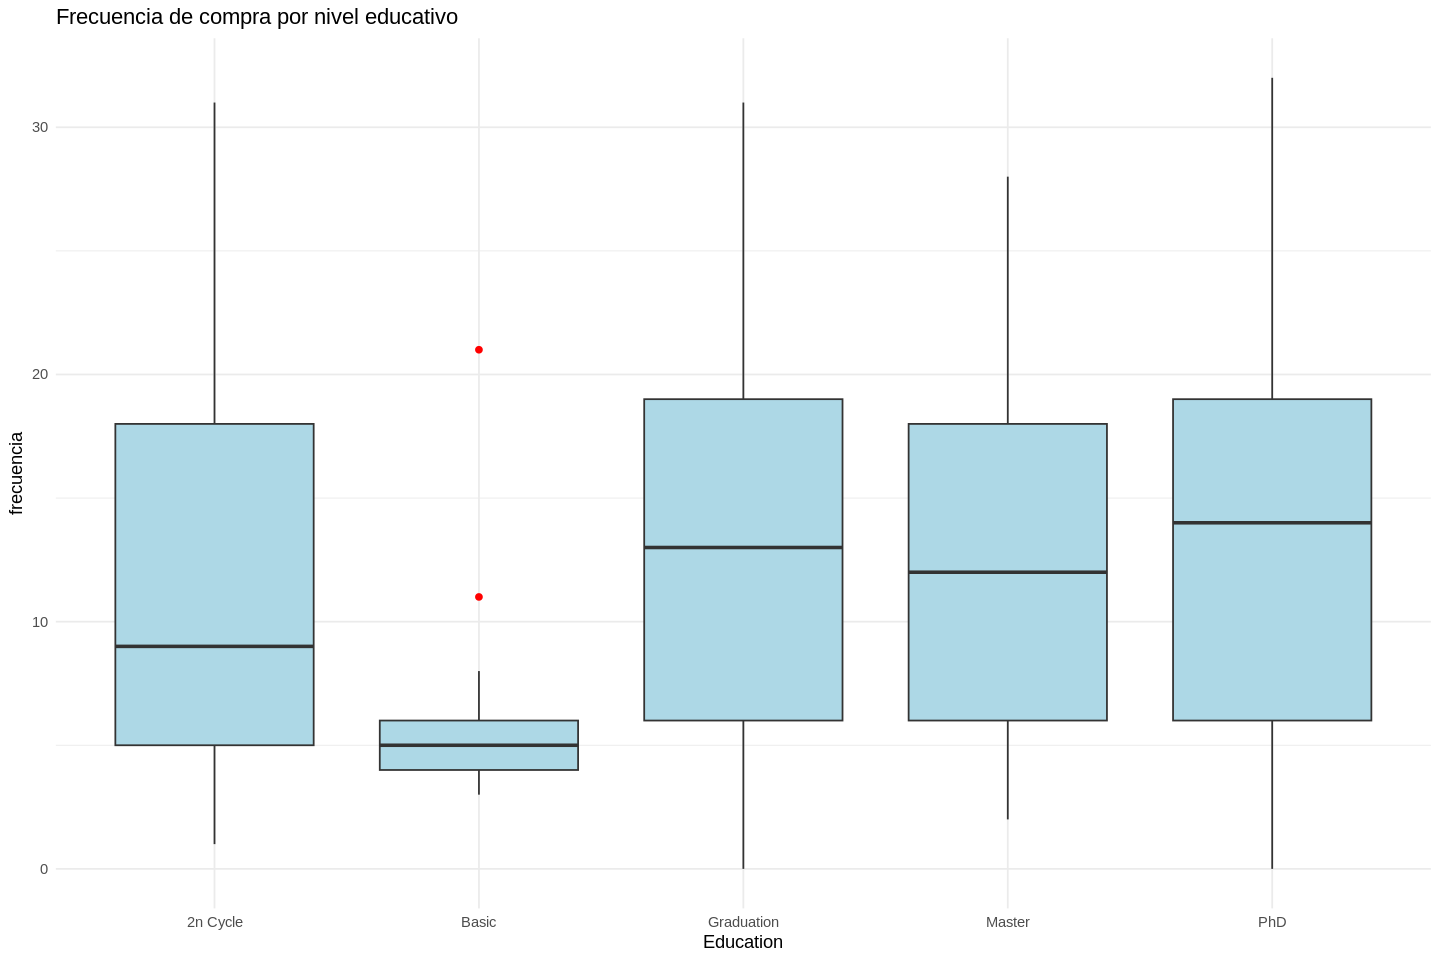

In [9]:
edu_summary <- marketing %>%
  group_by(Education) %>%
  summarise(
    promedio = mean(frecuencia, na.rm = TRUE),
    mediana = median(frecuencia, na.rm = TRUE),
    n = n()
  ) %>%
  arrange(desc(promedio))

cat('FRECUENCIA POR EDUCATION\n')
edu_summary

ggplot(marketing, aes(x = Education, y = frecuencia)) +
  geom_boxplot(fill = 'lightblue', outlier.color = 'red') +
  theme_minimal() +
  labs(title = 'Frecuencia de compra por nivel educativo')

marital_summary <- marketing %>%
  group_by(Marital_Status2) %>%
  summarise(
    promedio = mean(frecuencia, na.rm = TRUE),
    mediana = median(frecuencia, na.rm = TRUE),
    n = n()
  ) %>%
  arrange(desc(promedio))

cat('FRECUENCIA POR MARITAL_STATUS2\n')
marital_summary

hijos_summary <- marketing %>%
  group_by(tiene_hijos) %>%
  summarise(
    promedio = mean(frecuencia, na.rm = TRUE),
    mediana = median(frecuencia, na.rm = TRUE),
    n = n()
  )

cat('FRECUENCIA POR TIENE_HIJOS\n')
print(hijos_summary)

cat('Mayor frecuencia promedio por Education:', edu_summary$Education[1], '\n')
cat('Menor frecuencia promedio por Education:', edu_summary$Education[nrow(edu_summary)], '\n')
cat('Mayor frecuencia promedio por Marital_Status2:', marital_summary$Marital_Status2[1], '\n')

## P1c) Histograma de Income (clientes sin hijos)

La distribución del ingreso para clientes sin hijos presenta
 asimetría positiva (cola hacia la derecha).NO sigue una distribución normal perfecta.


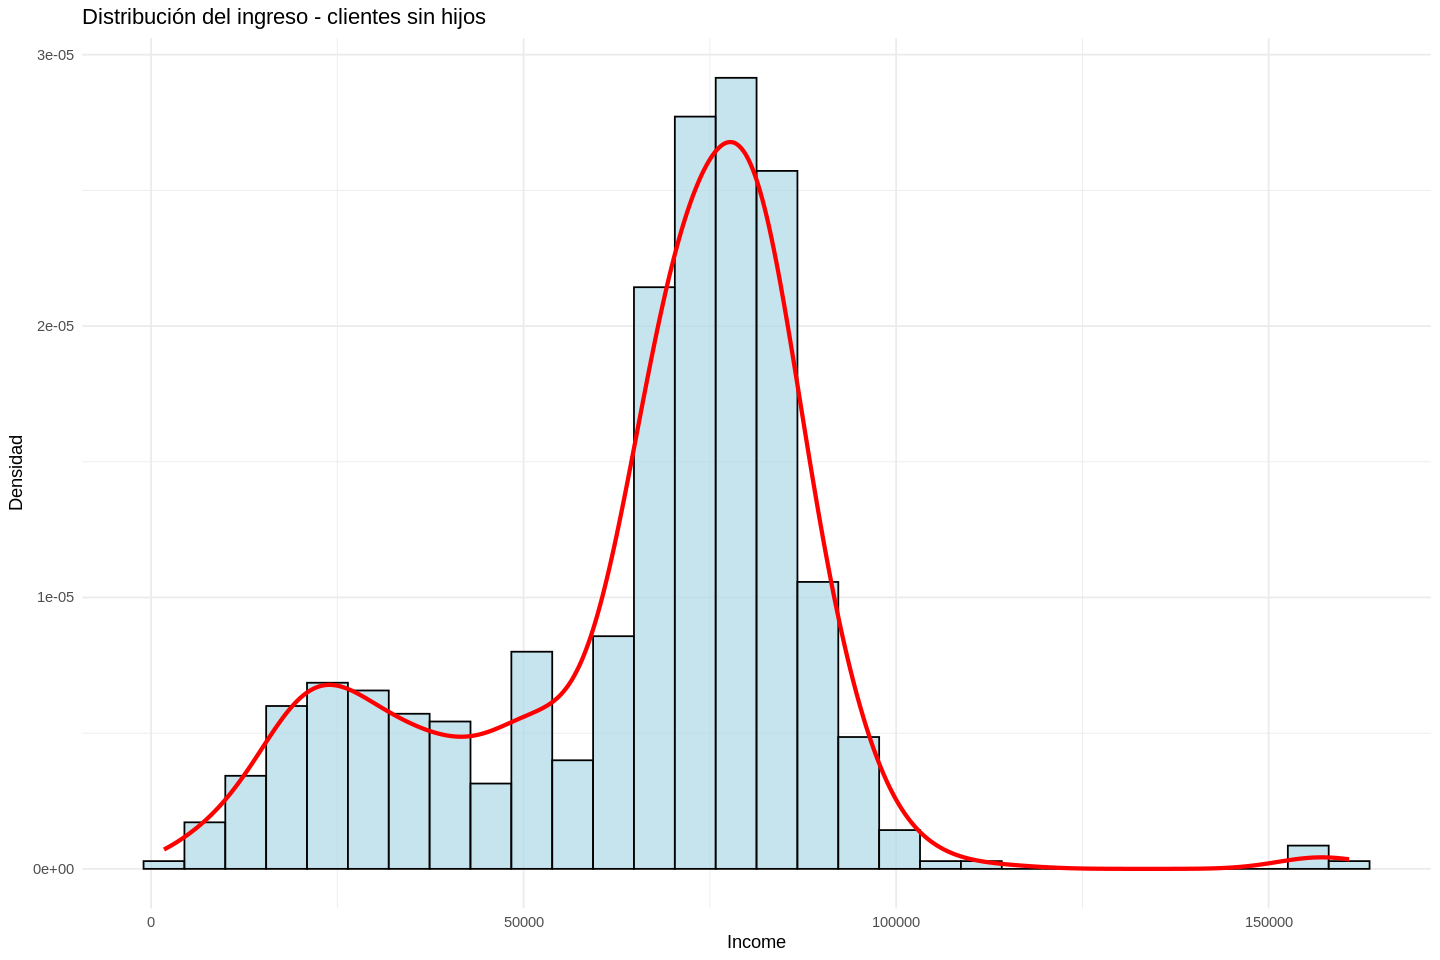

In [13]:
marketing_sin_hijos <- marketing %>% filter(tiene_hijos == 'NO')

ggplot(marketing_sin_hijos, aes(x = Income)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30,
                 fill = 'lightblue', color = 'black', alpha = 0.7) +
  geom_density(color = 'red', linewidth = 1.2) +
  theme_minimal() +
  labs(title = 'Distribución del ingreso - clientes sin hijos',
       x = 'Income', y = 'Densidad')

cat('La distribución del ingreso para clientes sin hijos presenta\n',
  'asimetría positiva (cola hacia la derecha).')
cat('NO sigue una distribución normal perfecta.\n')

## P2a) Crear quintiles RFM

In [14]:
marketing <- marketing %>%
  mutate(
    recency_cat = ntile(desc(Recency), 5),
    freq_cat = ntile(frecuencia, 5),
    Monto_cat = ntile(monto_total, 5)
  )

cat('Quintiles creados\n')
cat('Primeros 10 registros:')
marketing %>%
  select(ID, Recency, frecuencia, monto_total, recency_cat, freq_cat, Monto_cat) %>%
  head(10) %>%
  print()

Quintiles creados
Primeros 10 registros:     ID Recency frecuencia monto_total recency_cat freq_cat Monto_cat
1  5524      58         22        1617           3        5         5
2  2174      38          4          27           4        1         1
3  4141      26         20         776           4        4         4
4  6182      26          6          53           4        2         1
5  5324      94         14         422           1        3         3
6  7446      16         20         716           5        4         4
7   965      34         17         590           4        4         3
8  6177      32          8         169           4        2         2
9  4855      19          5          46           4        1         1
10 5899      68          1          49           2        1         1


## P2b) Calcular score ponderado

In [15]:
marketing <- marketing %>%
  mutate(
    score = 0.2 * recency_cat + 0.4 * freq_cat + 0.4 * Monto_cat
  )

cat('Score:\n')
summary(marketing$score)

Score:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       2       3       3       4       5 

## P2c) Score por categorías

In [16]:
score_edu <- marketing %>%
  group_by(Education) %>%
  summarise(
    promedio = mean(score, na.rm = TRUE),
    mediana = median(score, na.rm = TRUE),
    n = n()
  ) %>%
  arrange(desc(promedio))

cat('CORE POR EDUCATION\n')
score_edu

score_marital <- marketing %>%
  group_by(Marital_Status2) %>%
  summarise(
    promedio = mean(score, na.rm = TRUE),
    mediana = median(score, na.rm = TRUE),
    n = n()
  ) %>%
  arrange(desc(promedio))

cat('SCORE POR MARITAL_STATUS2\n')
score_marital

score_hijos <- marketing %>%
  group_by(tiene_hijos) %>%
  summarise(
    promedio = mean(score, na.rm = TRUE),
    mediana = median(score, na.rm = TRUE),
    n = n()
  )

cat('SCORE POR TIENE_HIJOS\n')
score_hijos

CORE POR EDUCATION


Education,promedio,mediana,n
<chr>,<dbl>,<dbl>,<int>
PhD,3.130041,3.4,486
Graduation,3.023425,3.2,1127
Master,3.016757,3.0,370
2n Cycle,2.838424,2.6,203
Basic,1.833333,1.8,54


SCORE POR MARITAL_STATUS2


Marital_Status2,promedio,mediana,n
<chr>,<dbl>,<dbl>,<int>
Desconocido,3.700000,3.4,4
Widow,3.309091,3.6,77
Divorced,3.025000,3.3,232
Married,3.001157,3.0,864
Together,2.981379,3.0,580
Single,2.953209,3.0,483


SCORE POR TIENE_HIJOS


tiene_hijos,promedio,mediana,n
<chr>,<dbl>,<dbl>,<int>
NO,3.720063,4.0,638
SI,2.713233,2.6,1602


## P2d) Dispersión score vs RatioGastosIngresos + outliers

OUTLIERS DETECTADOS
Número de outliers:  4 
IDs de outliers:  5376, 4246, 6237, 10311 
Scores de outliers:  4.6, 2.6, 3.4, 4.2 


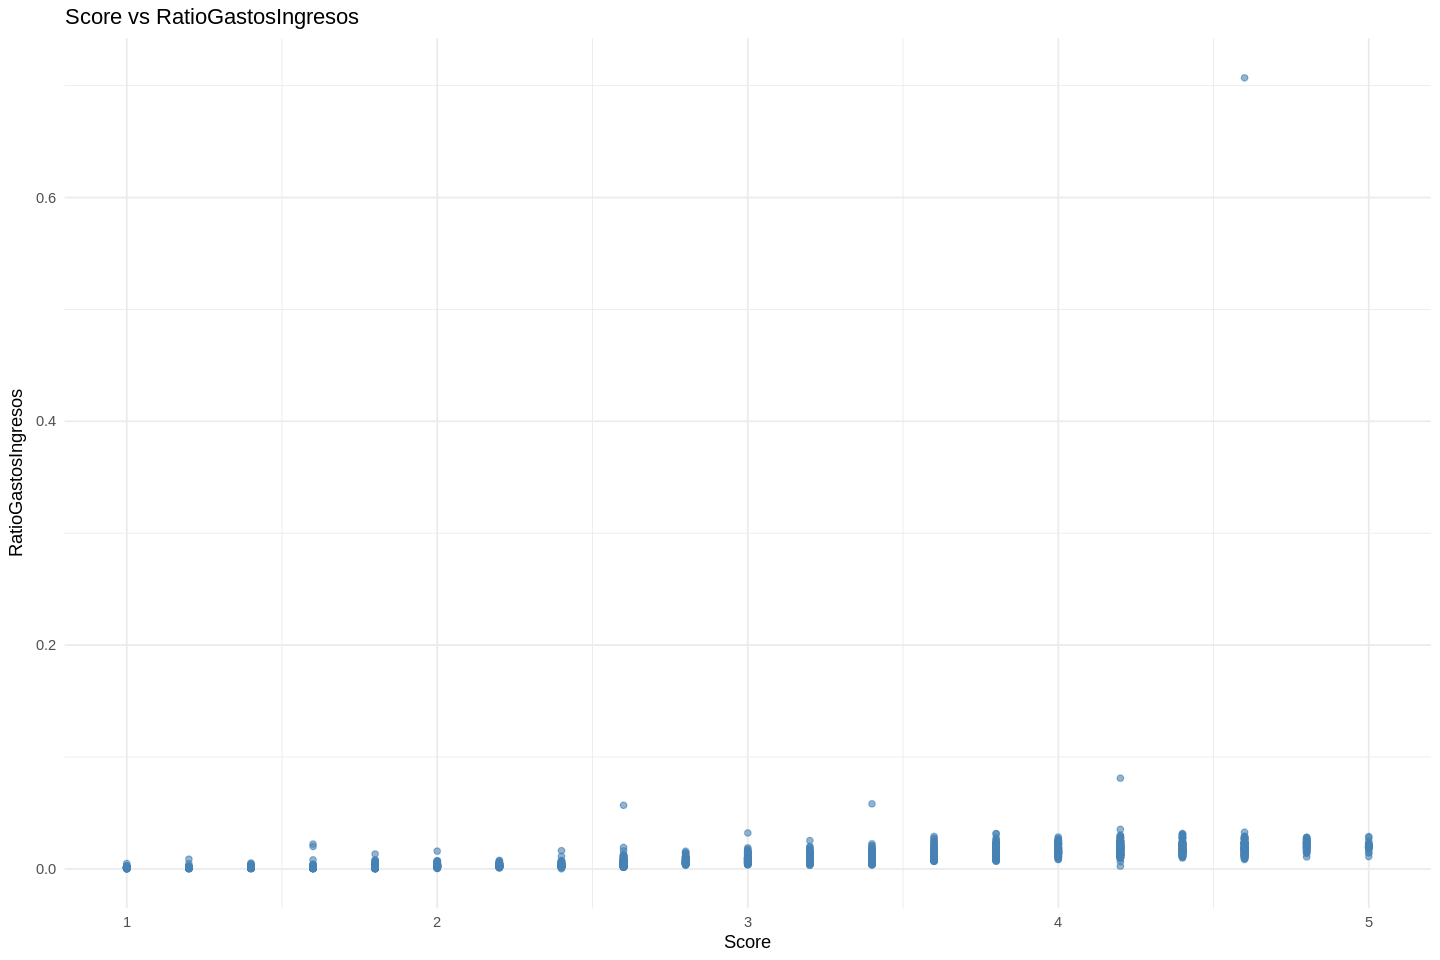

In [17]:
ggplot(marketing, aes(x = score, y = RatioGastosIngresos)) +
  geom_point(alpha = 0.6, color = 'steelblue') +
  theme_minimal() +
  labs(title = 'Score vs RatioGastosIngresos',
       x = 'Score', y = 'RatioGastosIngresos')

Q1 <- quantile(marketing$RatioGastosIngresos, 0.25, na.rm = TRUE)
Q3 <- quantile(marketing$RatioGastosIngresos, 0.75, na.rm = TRUE)
IQR_value <- Q3 - Q1
limite_sup <- Q3 + 1.5 * IQR_value

outliers <- marketing %>% filter(RatioGastosIngresos > limite_sup)

cat('OUTLIERS DETECTADOS\n')
cat('Número de outliers: ', nrow(outliers), '\n')
cat('IDs de outliers: ', paste(outliers$ID, collapse = ', '), '\n')
cat('Scores de outliers: ', paste(round(outliers$score, 2), collapse = ', '), '\n')

## P2e) Dispersión sin outliers + correlaciones

`geom_smooth()` using formula = 'y ~ x'



=== CORRELACIONES ===
Pearson: 0.8626 
Spearman: 0.9012 


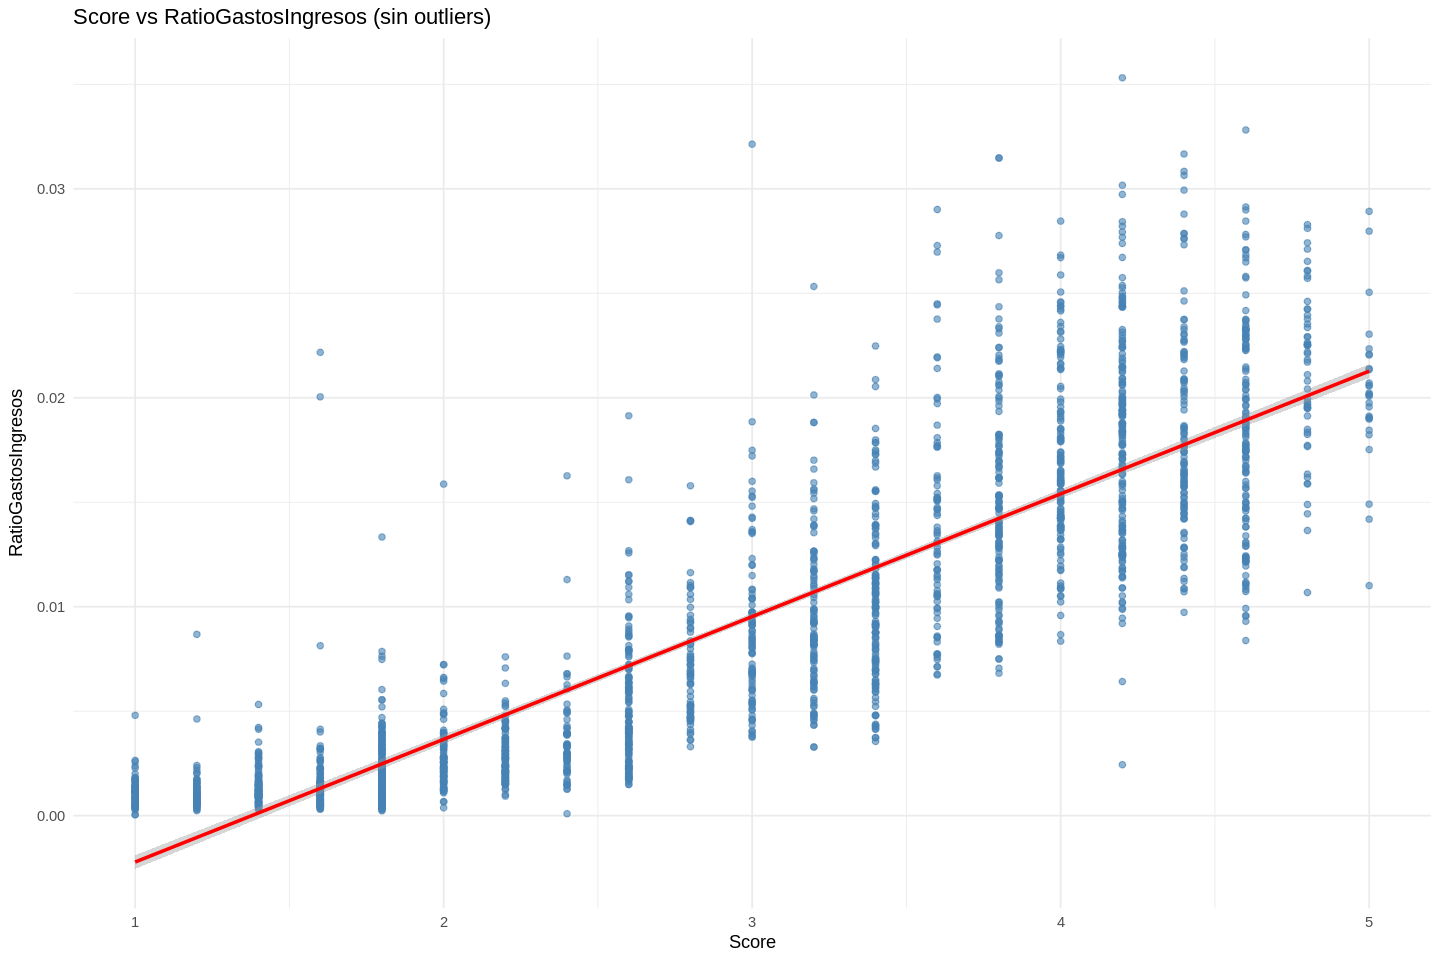

In [18]:
marketing_sin_outliers <- marketing %>%
  filter(RatioGastosIngresos <= limite_sup)

ggplot(marketing_sin_outliers, aes(x = score, y = RatioGastosIngresos)) +
  geom_point(alpha = 0.6, color = 'steelblue') +
  geom_smooth(method = 'lm', se = TRUE, color = 'red') +
  theme_minimal() +
  labs(title = 'Score vs RatioGastosIngresos (sin outliers)',
       x = 'Score', y = 'RatioGastosIngresos')

cor_pearson <- cor(marketing_sin_outliers$score,
                   marketing_sin_outliers$RatioGastosIngresos,
                   method = 'pearson', use = 'complete.obs')

cor_spearman <- cor(marketing_sin_outliers$score,
                    marketing_sin_outliers$RatioGastosIngresos,
                    method = 'spearman', use = 'complete.obs')

cat('CORRELACIONES\n')
cat('Pearson: ', round(cor_pearson, 4), '\n')
cat('Spearman: ', round(cor_spearman, 4), '\n')

## P2f) Dispersión por color = Education

`geom_smooth()` using formula = 'y ~ x'


CORRELACIONES POR EDUCATION


Education,Pearson,n
<chr>,<dbl>,<int>
Graduation,0.8695,1125
PhD,0.8512,485
Master,0.8702,369
Basic,0.7086,54
2n Cycle,0.8444,203


Mayor correlación:  Master 


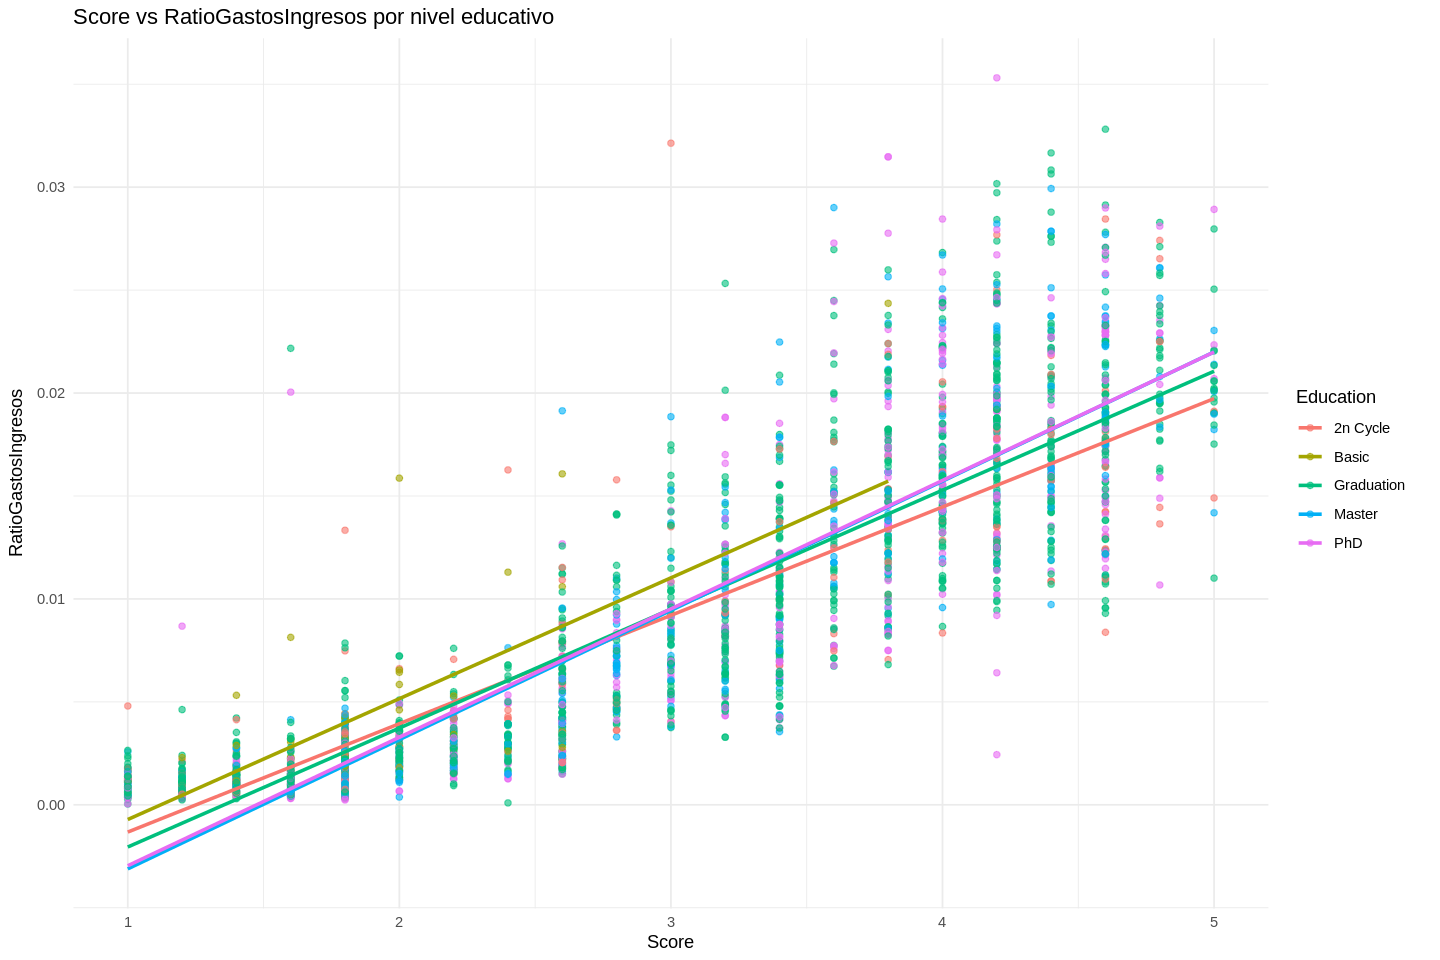

In [41]:
ggplot(marketing_sin_outliers, aes(x = score, y = RatioGastosIngresos, color = Education)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = 'lm', se = FALSE, linewidth = 1) +
  theme_minimal() +
  labs(title = 'Score vs RatioGastosIngresos por nivel educativo',
       x = 'Score', y = 'RatioGastosIngresos')

edu_levels <- unique(marketing_sin_outliers$Education)
cor_results <- data.frame()

for(edu in edu_levels) {
  subdata <- marketing_sin_outliers %>% filter(Education == edu)
  if(nrow(subdata) > 3) {
    pearson <- cor(subdata$score, subdata$RatioGastosIngresos,
                   method = 'pearson', use = 'complete.obs')
    cor_results <- rbind(cor_results, data.frame(
      Education = edu,
      Pearson = round(pearson, 4),
      n = nrow(subdata)
    ))
  }
}

cat('CORRELACIONES POR EDUCATION\n')
cor_results
cat('Mayor correlación: ', cor_results$Education[which.max(cor_results$Pearson)], '\n')

# SECCIÓN 2 - CAFETERÍA
## Carga y limpieza de datos

In [42]:
trans_original <- read.csv('data/cafeteria.csv', stringsAsFactors = FALSE)
trans_original <- trans_original %>% filter(Item != 'NONE')

cat('Datos cargados\n')
cat('Filas: ', nrow(trans_original), '\n')
cat('Items únicos: ', n_distinct(trans_original$Item), '\n')

Datos cargados
Filas:  20507 
Items únicos:  94 


## P1) Extraer hora, minutos y segundos

In [43]:
trans_original <- trans_original %>%
  mutate(
    hora = as.integer(substr(Time, 1, 2)),
    minutos = as.integer(substr(Time, 4, 5)),
    segundos = as.integer(substr(Time, 7, 8))
  )

cat('Hora, minutos y segundos extraídos\n')
head(trans_original)

Hora, minutos y segundos extraídos


,Date,Time,Transaction,Item,hora,minutos,segundos
,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>
1,2016-10-30,09:58:11,1,Bread,9,58,11
2,2016-10-30,10:05:34,2,Scandinavian,10,5,34
3,2016-10-30,10:05:34,2,Scandinavian,10,5,34
4,2016-10-30,10:07:57,3,Hot chocolate,10,7,57
5,2016-10-30,10:07:57,3,Jam,10,7,57
6,2016-10-30,10:07:57,3,Cookies,10,7,57


## P2) Tabla resumen por hora

In [44]:
resumen_hora <- trans_original %>%
  group_by(hora) %>%
  summarise(
    total_trx = n_distinct(Transaction),
    total_items = n(),
    total_items_unicos = n_distinct(Item)
  ) %>%
  arrange(hora)

cat('Tabla resumen por hora\n')
resumen_hora

Tabla resumen por hora


hora,total_trx,total_items,total_items_unicos
<int>,<int>,<int>,<int>
1,1,1,1
7,16,24,5
8,375,645,42
9,1006,1966,48
10,1266,2666,63
11,1439,3102,65
12,1325,2854,65
13,1143,2617,68
14,1120,2640,67


## P3) Horas punta y no punta

In [40]:
horas_punta <- resumen_hora %>% filter(total_trx > 1000)
horas_no_punta <- resumen_hora %>% filter(total_trx <= 1000)

cat('HORAS PUNTA\n')
cat('Horas con > 1.000 transacciones: ', paste(horas_punta$hora, collapse = ', '), '\n')

prom_punta <- mean(horas_punta$total_trx)
prom_no_punta <- mean(horas_no_punta$total_trx)

cat('PROMEDIO\n')
cat('Promedio en hora punta: ', round(prom_punta, 2), '\n')
cat('Promedio en hora no punta: ', round(prom_no_punta, 2), '\n')

HORAS PUNTA
Horas con > 1.000 transacciones:  9, 10, 11, 12, 13, 14 
PROMEDIO
Promedio en hora punta:  1216.5 
Promedio en hora no punta:  180.5 


## P4) Top 5 items más vendidos

Primeros 5 items MÁS VENDIDOS


Item,total
<chr>,<int>
Coffee,5471
Bread,3325
Tea,1435
Cake,1025
Pastry,856


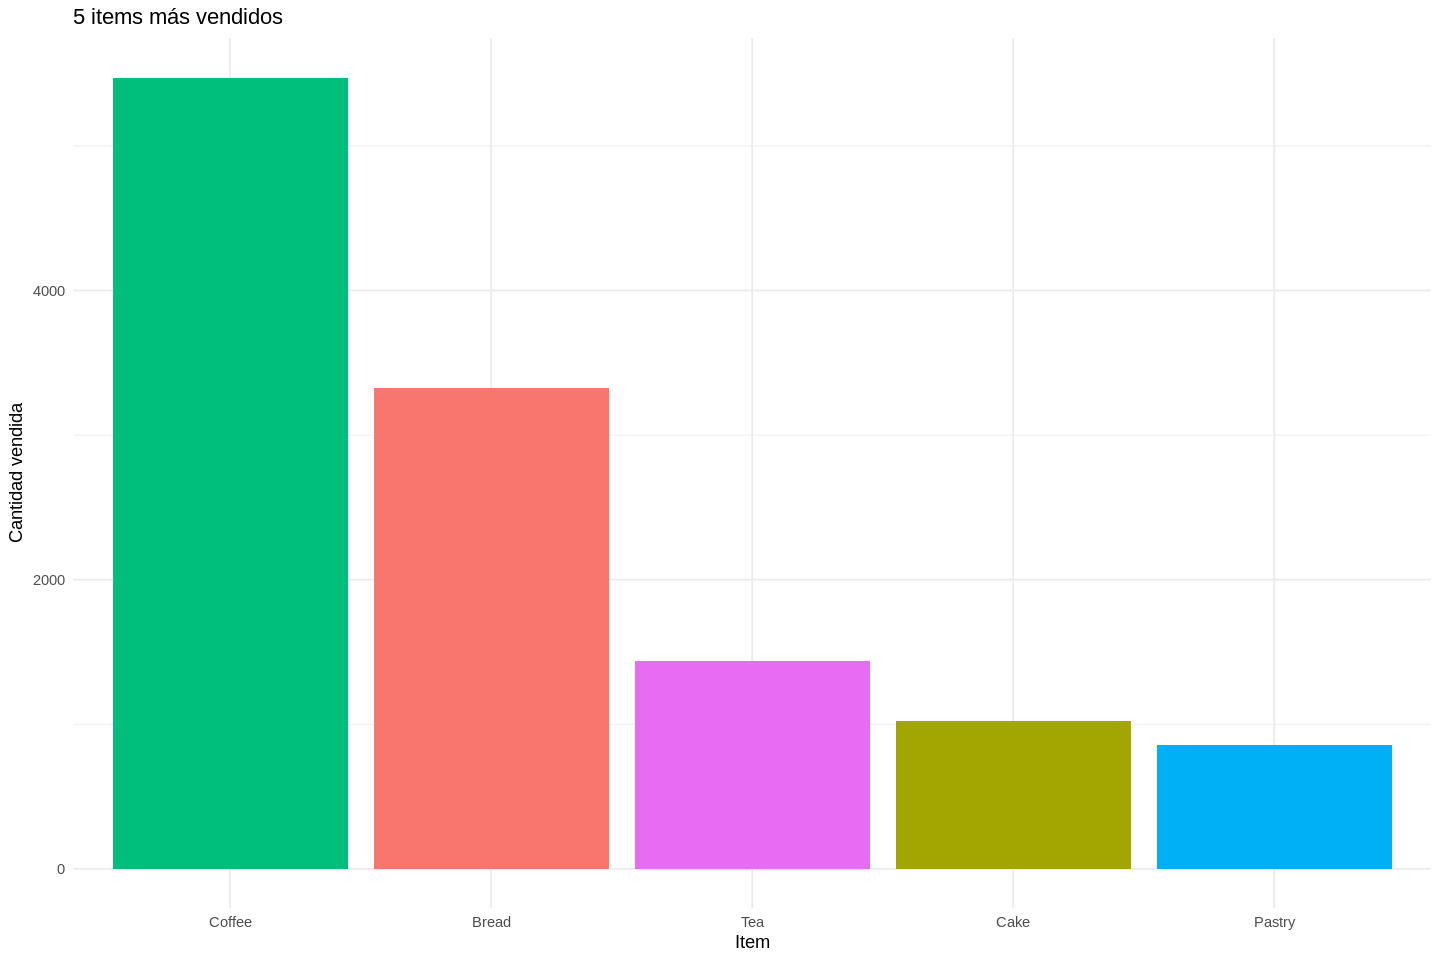

In [47]:
top_items <- trans_original %>%
  group_by(Item) %>%
  summarise(total = n()) %>%
  arrange(desc(total)) %>%
  head(5)

cat('Primeros 5 items MÁS VENDIDOS\n')
top_items

ggplot(top_items, aes(x = reorder(Item, -total), y = total, fill = Item)) +
  geom_col() +
  theme_minimal() +
  labs(title = '5 items más vendidos', x = 'Item', y = 'Cantidad vendida') +
  theme(legend.position = 'none')

## P5) Top 5 items por rango horario

In [46]:
trans_original <- trans_original %>%
  mutate(
    rango_horario = case_when(
      hora >= 7 & hora < 12 ~ '7:00-11:59',
      hora >= 12 & hora < 17 ~ '12:00-16:59',
      hora >= 17 & hora < 24 ~ '17:00-23:59',
      TRUE ~ 'Otro'
    )
  )

top_por_rango <- function(rango) {
  trans_original %>%
    filter(rango_horario == rango) %>%
    group_by(Item) %>%
    summarise(total = n()) %>%
    arrange(desc(total)) %>%
    head(5)
}

cat('7:00-11:59:\n')
top_por_rango('7:00-11:59')

cat('12:00-16:59:\n')
top_por_rango('12:00-16:59')

cat('17:00-23:59:\n')
top_por_rango('17:00-23:59')

7:00-11:59:


Item,total
<chr>,<int>
Coffee,2561
Bread,1609
Pastry,604
Tea,456
Medialuna,402


12:00-16:59:


Item,total
<chr>,<int>
Coffee,2823
Bread,1661
Tea,930
Cake,731
Sandwich,671


17:00-23:59:


Item,total
<chr>,<int>
Coffee,87
Bread,54
Tea,49
Cake,30
Hot chocolate,23


## P6) Reglas de asociación por rango horario

In [57]:
generar_reglas <- function(rango, support = 0.02, confidence = 0.1) {

  datos_rango <- trans_original %>% filter(rango_horario == rango)
  transacciones <- split(datos_rango$Item, datos_rango$Transaction)
  transacciones <- as(transacciones, 'transactions')
  reglas <- apriori(transacciones,
                    parameter = list(supp = support, conf = confidence, minlen = 2, maxlen = 5),
                    control = list(verbose = FALSE))

  reglas_filtradas <- subset(reglas, size(lhs) > 0 & size(rhs) > 0)
  return(reglas_filtradas)

}

rangos <- c('7:00-11:59', '12:00-16:59', '17:00-23:59')
rangos
for(rango in rangos) {
  cat('\nRANGO:\n', rango, '\n')

  reglas <- tryCatch({
    generar_reglas(rango, support = 0.02, confidence = 0.1)
  }, error = function(e) {
    cat('Con soporte 0.02 no se generaron reglas. Ajustando a 0.01\n')
    generar_reglas(rango, support = 0.01, confidence = 0.1)
  })

  if(length(reglas) > 0) {
    regla_frecuente <- sort(reglas, by = 'support', decreasing = TRUE)[1]
    cat('Regla más frecuente:')
    inspect(regla_frecuente)

    regla_confianza <- sort(reglas, by = 'confidence', decreasing = TRUE)[1]
    cat('Regla con mayor confidence:')
    inspect(regla_confianza)

    regla_lift <- sort(reglas, by = 'lift', decreasing = TRUE)[1]
    cat('Regla con mayor lift:\n')
    inspect(regla_lift)
  } else {
    cat('No se generaron reglas para este rango.\n')
  }
}

[1] "7:00-11:59"  "12:00-16:59" "17:00-23:59"


RANGO:
 7:00-11:59 


Warning message in asMethod(object):
“removing duplicated items in transactions”


Regla más frecuente:    lhs        rhs      support    confidence coverage  lift      count
[1] {Bread} => {Coffee} 0.09410044 0.2592344  0.3629937 0.5032558 386  
Regla con mayor confidence:    lhs        rhs      support    confidence coverage   lift     count
[1] {Toast} => {Coffee} 0.03583618 0.7205882  0.04973184 1.398889 147  
Regla con mayor lift:
    lhs        rhs      support    confidence coverage   lift     count
[1] {Toast} => {Coffee} 0.03583618 0.7205882  0.04973184 1.398889 147  

RANGO:
 12:00-16:59 


Warning message in asMethod(object):
“removing duplicated items in transactions”


Regla más frecuente:    lhs        rhs      support    confidence coverage  lift      count
[1] {Bread} => {Coffee} 0.08999803 0.2943445  0.3057575 0.6401363 458  
Regla con mayor confidence:    lhs         rhs      support    confidence coverage   lift   count
[1] {Pastry} => {Coffee} 0.02554529 0.5579399  0.04578503 1.2134 130  
Regla con mayor lift:
    lhs       rhs   support    confidence coverage  lift    count
[1] {Cake} => {Tea} 0.03261938 0.2385057  0.1367656 1.40481 166  

RANGO:
 17:00-23:59 


Warning message in asMethod(object):
“removing duplicated items in transactions”


Regla más frecuente:    lhs       rhs      support    confidence coverage  lift count
[1] {Cake} => {Coffee} 0.05860806 0.5714286  0.1025641 2.08 16   
Regla con mayor confidence:    lhs           rhs      support    confidence coverage   lift count
[1] {Postcard} => {Tshirt} 0.02197802 0.6        0.03663004 7.8  6    
Regla con mayor lift:
    lhs         rhs        support    confidence coverage   lift count
[1] {Tshirt} => {Postcard} 0.02197802 0.2857143  0.07692308 7.8  6    


## P7) Reglas con Coffee en antecedente

In [56]:
cat('REGLAS CON COFFEE EN ANTECEDENTE\n')

for(rango in rangos) {
  print('\nRANGO:')
  rango
  print(' / Intentando generar reglas\n')

  reglas <- tryCatch({
    generar_reglas(rango, support = 0.01, confidence = 0.1)
  }, error = function(e) {
    cat('Falló para el rango con support 0.01')
    rango
    cat('Intentando con support 0.005 y confidence 0.05...\n')
    generar_reglas(rango, support = 0.005, confidence = 0.05)
  })

  if (is.null(reglas) || length(reglas) == 0) {
    cat('No se pudieron generar reglas para el rango', rango, 'incluso con soporte reducido.\n')
    next
  }

  reglas_coffee <- subset(reglas, lhs %in% 'Coffee')

  if(length(reglas_coffee) > 0) {
    cat('* Rango: Reglas con Coffee en antecedente')
    rango
    inspect(sort(reglas_coffee, by = 'support', decreasing = TRUE))

    cat('* Rango: Promoción recomendada:')
    rango
    df_reglas <- as(reglas_coffee, 'data.frame')
    df_reglas <- df_reglas %>%
      arrange(desc(confidence), desc(lift)) %>%
      head(3)

    if(nrow(df_reglas) > 0) {
      mejor <- df_reglas[1,]
      cat('MEJOR PROMO:')
      mejor$rules
      cat('Support:')
      round(mejor$support, 4)
      cat('Confidence:')
      round(mejor$confidence, 3)
      cat('Lift:')
      round(mejor$lift, 3)
    } else {
      cat('No se pudo determinar la mejor promoción para este rango.\n')
    }
  } else {
    cat('No se encontraron reglas con Coffee en antecedente para el rango')
    rango
  }
  cat('--- RANGO:', rango, 'FINALIZADO ---\n')
}
cat('--- ANÁLISIS DE REGLAS FINALIZADO ---\n')

REGLAS CON COFFEE EN ANTECEDENTE
[1] "\nRANGO:"
[1] " / Intentando generar reglas\n"


Warning message in asMethod(object):
“removing duplicated items in transactions”


* Rango: Reglas con Coffee en antecedente    lhs                    rhs         support    confidence coverage  
[1] {Coffee}            => {Bread}     0.09410044 0.1826787  0.51511458
[2] {Coffee}            => {Pastry}    0.07727938 0.1500237  0.51511458
[3] {Coffee}            => {Medialuna} 0.05460751 0.1060104  0.51511458
[4] {Coffee, Pastry}    => {Bread}     0.01608971 0.2082019  0.07727938
[5] {Bread, Coffee}     => {Pastry}    0.01608971 0.1709845  0.09410044
[6] {Coffee, Medialuna} => {Bread}     0.01097026 0.2008929  0.05460751
[7] {Bread, Coffee}     => {Medialuna} 0.01097026 0.1165803  0.09410044
    lift      count
[1] 0.5032558 386  
[2] 1.0758690 317  
[3] 1.1443545 224  
[4] 0.5735689  66  
[5] 1.2261857  66  
[6] 0.5534335  45  
[7] 1.2584538  45  
* Rango: Promoción recomendada:MEJOR PROMO:Support:Confidence:Lift:--- RANGO: 7:00-11:59 FINALIZADO ---
[1] "\nRANGO:"
[1] " / Intentando generar reglas\n"


Warning message in asMethod(object):
“removing duplicated items in transactions”


* Rango: Reglas con Coffee en antecedente     lhs                   rhs        support    confidence coverage  
[1]  {Coffee}           => {Bread}    0.08999803 0.1957265  0.45981529
[2]  {Coffee}           => {Cake}     0.07191983 0.1564103  0.45981529
[3]  {Coffee}           => {Sandwich} 0.06229122 0.1354701  0.45981529
[4]  {Coffee}           => {Tea}      0.05718216 0.1243590  0.45981529
[5]  {Cake, Coffee}     => {Tea}      0.01355866 0.1885246  0.07191983
[6]  {Coffee, Tea}      => {Cake}     0.01355866 0.2371134  0.05718216
[7]  {Cake, Coffee}     => {Bread}    0.01355866 0.1885246  0.07191983
[8]  {Bread, Coffee}    => {Cake}     0.01355866 0.1506550  0.08999803
[9]  {Coffee, Sandwich} => {Bread}    0.01198664 0.1924290  0.06229122
[10] {Bread, Coffee}    => {Sandwich} 0.01198664 0.1331878  0.08999803
     lift      count
[1]  0.6401363 458  
[2]  1.1436376 366  
[3]  1.1684869 317  
[4]  0.7324801 291  
[5]  1.1104186  69  
[6]  1.7337214  69  
[7]  0.6165820  69  
[8]  1.101

Warning message in asMethod(object):
“removing duplicated items in transactions”


* Rango: Reglas con Coffee en antecedente     lhs                        rhs             support    confidence
[1]  {Coffee}                => {Cake}          0.05860806 0.2133333 
[2]  {Coffee}                => {Tea}           0.04761905 0.1733333 
[3]  {Coffee}                => {Alfajores}     0.03296703 0.1200000 
[4]  {Coffee}                => {Hot chocolate} 0.03296703 0.1200000 
[5]  {Coffee}                => {Cookies}       0.03296703 0.1200000 
[6]  {Coffee}                => {Bread}         0.02930403 0.1066667 
[7]  {Cake, Coffee}          => {Tea}           0.01465201 0.2500000 
[8]  {Coffee, Tea}           => {Cake}          0.01465201 0.3076923 
[9]  {Coffee, Medialuna}     => {Tea}           0.01098901 0.4285714 
[10] {Coffee, Tea}           => {Medialuna}     0.01098901 0.2307692 
[11] {Coffee, Hot chocolate} => {Cake}          0.01098901 0.3333333 
[12] {Cake, Coffee}          => {Hot chocolate} 0.01098901 0.1875000 
[13] {Coffee, Cookies}       => {Tea}           0

## RESUMEN EJECUTIVO FINAL
---

## 1. ANÁLISIS DE CLIENTES (RFM)
- Mayor frecuencia de compra: **Graduation** y **Together**
- Clientes sin hijos tienen mejor score promedio
- Correlación moderada entre Score y RatioGastosIngresos

## 2. ANÁLISIS DE CAFETERÍA
- Item más vendido: **Coffee**
- Horas punta: **10:00-11:00**
- En horario punta se venden más de 1000 transacciones/hora

## 3. RECOMENDACIONES
- Enfocar promociones en productos asociados a Coffee
- Ajustar personal y stock según horarios punta
- Segmentar clientes según nivel educativo para campañas
